# End-to-End OCR System (Detection + Transformer Recognition)

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.2 MB/s eta 0:00:00


In [ ]:
import os
import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from sklearn.model_selection import train_test_split
import evaluate
import torchvision.transforms as T
from torchvision import models

## Text Detection Model

###Dataset & Preprocessing

In [ ]:
class TextOCRDataset(Dataset):
    def __init__(self, annot_csv, image_root, image_ids=None, transform=None):
        self.annot_df = pd.read_csv(annot_csv)
        self.image_root = image_root
        self.transform = transform

        all_ids = self.annot_df['image_id'].unique()
        self.image_ids = image_ids if image_ids is not None else all_ids

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.image_root, f"{image_id}.jpg")
        image = np.array(Image.open(img_path).convert("RGB"))

        h, w = image.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)

        anns = self.annot_df[self.annot_df['image_id'] == image_id]
        for _, row in anns.iterrows():
            bbox = eval(row['bbox'])
            x, y, bw, bh = map(int, bbox)
            x2 = min(x + bw, w)
            y2 = min(y + bh, h)
            cv2.rectangle(mask, (x, y), (x2, y2), color=255, thickness=-1)

        image = torch.tensor(image).permute(2, 0, 1).float() / 255.
        mask = torch.tensor(mask).unsqueeze(0).float() / 255.

        return image, mask, image_id

###Segmentation Model (ResNet18-based)

In [ ]:
class ResNet18Seg(nn.Module):
    def __init__(self, weights=torchvision.models.ResNet18_Weights.DEFAULT):
        super().__init__()
        backbone = torchvision.models.resnet18(weights=weights)
        self.encoder = nn.Sequential(*list(backbone.children())[:-2])

        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        feats = self.encoder(x)
        out = self.decoder(feats)
        out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=False)
        return out


### Training Pipeline

In [ ]:
# --- Model & Optimizer ---
epochs = 20
start_epoch = 0
best_val_loss = float('inf')
model = ResNet18Seg()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- Data Preparation ---
all_annot = pd.read_csv("data/annot.csv")
unique_ids = all_annot['image_id'].unique()
valid_ids = []
for image_id in unique_ids:
    img_path = f"data/train_val_images/train_images/{image_id}.jpg"
    if not os.path.exists(img_path):
        continue
    try:
        img = Image.open(img_path)
        if img.width <= 3000 and img.height <= 3000:
            valid_ids.append(image_id)
    except:
        pass
train_ids, val_ids = train_test_split(valid_ids, train_size=10000, test_size=2000, random_state=42)
train_set = TextOCRDataset("data/annot.csv", "data/train_val_images/train_images", train_ids)
val_set   = TextOCRDataset("data/annot.csv", "data/train_val_images/train_images", val_ids)
train_loader = DataLoader(train_set, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=1, shuffle=False)

# Loss
criterion = nn.BCELoss()

# --- Training & Validation ---
for epoch in range(start_epoch, epochs):
    # Training
    model.train()
    train_loss = 0.0
    for imgs, masks, _ in tqdm(train_loader, desc=f"Training {epoch+1}/{epochs}"):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks, image_ids in tqdm(val_loader, desc="Validating", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best.pth")
        print("Saved best model.")

### Post-processing & Bounding Box Extraction

In [ ]:
def prepare_image(filepath):
    img = Image.open(filepath).convert("RGB")
    arr = np.array(img)
    tensor_img = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).float() / 255.
    return arr, tensor_img

def extract_bounding_boxes(prob_map, bin_thresh=0.8, min_size=50):
    normalized = (prob_map - np.min(prob_map)) / (np.max(prob_map) - np.min(prob_map) + 1e-8)
    binary_map = (normalized > bin_thresh).astype(np.uint8)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    processed = cv2.morphologyEx(binary_map, cv2.MORPH_OPEN, kernel)

    _, labeled, stats, _ = cv2.connectedComponentsWithStats(processed, connectivity=8)

    detected = []
    for i, s in enumerate(stats[1:], 1):
        x, y, w, h, area = s
        if area < min_size:
            continue

        detected.append((x, y, w, h))

    return detected

def display_results(original, boxes, out_path=None):
    vis_img = original.copy()
    for x, y, w, h in boxes:
        cv2.rectangle(vis_img, (x-2, y-2), (x+w+4, y+h+4), (0, 255, 0), 1)

    plt.figure(figsize=(10, 10))
    plt.imshow(vis_img)
    plt.axis("off")
    if out_path:
        plt.savefig(out_path, bbox_inches="tight")
    plt.show()

def detect_box(img_path):
  # Load trained segmentation model
  model = ResNet18Seg()
  ckpt = torch.load("best.pth", map_location="cpu")
  model.load_state_dict(ckpt["model"])
  model.eval()
  image_np, input_tensor = prepare_image(img_file)

  with torch.no_grad():
      prediction = model(input_tensor)[0, 0].numpy()

  # Extract and visualize bounding boxes
  boxes = extract_bounding_boxes(prediction, bin_thresh=0.9, min_size=500)

  print(f"Total boxes detected: {len(boxes)}")

  print(boxes)

  display_results(image_np, boxes, out_path="predicted_result.jpg")


Total boxes detected: 8
[(377, 914, 50, 21), (279, 910, 89, 27), (353, 329, 144, 30), (217, 329, 122, 28), (315, 208, 176, 62), (221, 205, 83, 60), (355, 133, 201, 64), (163, 131, 180, 65)]


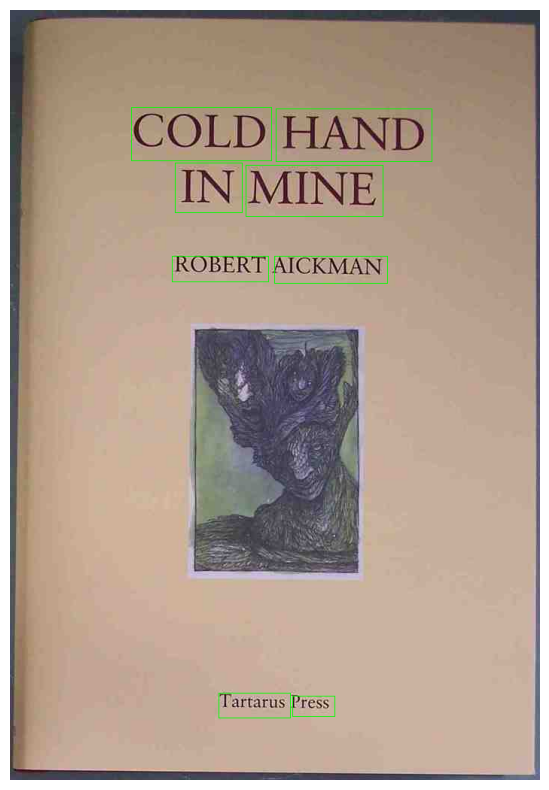

In [ ]:
  img_file = "sach.jpg"
  detect_box(img_file)

##Text Recognition Model

###Vocabulary Construction & Tokenization

In [ ]:
def build_vocab():
    # Tổng hợp tất cả các ký tự xuất hiện trong utf8_string
    characters = [ # Chữ thường
            'a', 'à', 'á', 'ả', 'ã', 'ạ',
            'ă', 'ằ', 'ắ', 'ẳ', 'ẵ', 'ặ',
            'â', 'ầ', 'ấ', 'ẩ', 'ẫ', 'ậ',
            'b', 'c', 'd', 'đ',
            'e', 'è', 'é', 'ẻ', 'ẽ', 'ẹ',
            'ê', 'ề', 'ế', 'ể', 'ễ', 'ệ',
            'f', 'g', 'h',
            'i', 'ì', 'í', 'ỉ', 'ĩ', 'ị',
            'j', 'k', 'l', 'm', 'n',
            'o', 'ò', 'ó', 'ỏ', 'õ', 'ọ',
            'ô', 'ồ', 'ố', 'ổ', 'ỗ', 'ộ',
            'ơ', 'ờ', 'ớ', 'ở', 'ỡ', 'ợ',
            'p', 'q', 'r', 's', 't',
            'u', 'ù', 'ú', 'ủ', 'ũ', 'ụ',
            'ư', 'ừ', 'ứ', 'ử', 'ữ', 'ự',
            'v', 'w', 'x', 'y', 'ỳ', 'ý', 'ỷ', 'ỹ', 'ỵ', 'z',
            # Chữ hoa
            'A', 'À', 'Á', 'Ả', 'Ã', 'Ạ',
            'Ă', 'Ằ', 'Ắ', 'Ẳ', 'Ẵ', 'Ặ',
            'Â', 'Ầ', 'Ấ', 'Ẩ', 'Ẫ', 'Ậ',
            'B', 'C', 'D', 'Đ',
            'E', 'È', 'É', 'Ẻ', 'Ẽ', 'Ẹ',
            'Ê', 'Ề', 'Ế', 'Ể', 'Ễ', 'Ệ',
            'F', 'G', 'H',
            'I', 'Ì', 'Í', 'Ỉ', 'Ĩ', 'Ị',
            'J', 'K', 'L', 'M', 'N',
            'O', 'Ò', 'Ó', 'Ỏ', 'Õ', 'Ọ',
            'Ô', 'Ồ', 'Ố', 'Ổ', 'Ỗ', 'Ộ',
            'Ơ', 'Ờ', 'Ớ', 'Ở', 'Ỡ', 'Ợ',
            'P', 'Q', 'R', 'S', 'T',
            'U', 'Ù', 'Ú', 'Ủ', 'Ũ', 'Ụ',
            'Ư', 'Ừ', 'Ứ', 'Ử', 'Ữ', 'Ự',
            'V', 'W', 'X', 'Y', 'Ỳ', 'Ý', 'Ỷ', 'Ỹ', 'Ỵ', 'Z',
            # Dấu câu và ký tự đặc biệt
            ' ', '!', '"', '#', '$', '%', '&', '\'', '(', ')', '*', '+', ',', '-', '.', '/',
            '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
            ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~'
        ]

    # Thêm các token đặc biệt
    special_tokens = ['<pad>', '<sos>', '<eos>', '*']

    # Tạo vocabulary hoàn chỉnh
    vocab = special_tokens + sorted(characters)

    # Tạo mappings
    char_to_idx = {char: idx for idx, char in enumerate(vocab)}
    idx_to_char = {idx: char for idx, char in enumerate(vocab)}


    return vocab, char_to_idx, idx_to_char

### Input Preprocessing

In [ ]:
class OCRAnnotationDataset(Dataset):
    def __init__(self, annot_df, img_csv, img_root, char_to_idx, max_len=100,data='train'):
        self.annot_df = annot_df
        self.img_df = pd.read_csv(img_csv)
        self.img_root = img_root
        self.char_to_idx = char_to_idx
        self.max_len = max_len
        self.data=data
        if data=='train':
            self.transform = T.Compose([
                T.ToPILImage(),
                T.Grayscale(),
                T.RandomAffine(
                    degrees=3,
                    translate=(0.01, 0.01),
                    scale=(0.95, 1.05),
                    shear=2
                ),
                T.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                ),
                T.Resize((64, 256)),
                T.ToTensor(),
                T.Normalize((0.5,), (0.5,))
            ])
        else:
            self.transform = T.Compose([
                T.ToPILImage(),
                T.Grayscale(),
                T.Resize((64, 256)),
                T.ToTensor(),
                T.Normalize((0.5,), (0.5,))
                 ])

    def encode_label(self, text):

        if not isinstance(text, str):
            text = str(text)

        label = [self.char_to_idx['<sos>']] + \
                [self.char_to_idx[c] for c in text if c in self.char_to_idx] + \
                [self.char_to_idx['<eos>']]
        if len(label) < self.max_len:
            label += [self.char_to_idx['<pad>']] * (self.max_len - len(label))
        else:
            label = label[:self.max_len]
        return torch.tensor(label)

    def __getitem__(self, idx):
        row = self.annot_df.iloc[idx]
        image_id = row['image_id']
        img_path = f"data\\train_val_images\\train_images\\{image_id}.jpg"

        # Load ảnh gốc
        img = cv2.imread(img_path)

        # Lấy bbox
        h_img, w_img = img.shape[:2]
        x, y, w, h = eval(row['bbox'])

        x1 = max(0, int(x))
        y1 = max(0, int(y))
        x2 = min(w_img, int(x + w))
        y2 = min(h_img, int(y + h))
        # nếu bbox không hợp lệ thì fallback
        if x2 <= x1 or y2 <= y1:
            x1, y1, x2, y2 = 0, 0, w_img, h_img

        crop_img = img[y1:y2, x1:x2]
        crop_up_img = cv2.resize(crop_img, (w*2, h*2), interpolation=cv2.INTER_CUBIC)

        # Xử lý tensor ảnh
        img_tensor = self.transform(crop_up_img)

        # Encode label
        label_tensor = self.encode_label(row['utf8_string'])

        return img_tensor, label_tensor

    def __len__(self):
        return len(self.annot_df)


### CNN + Transformer Decoder Architecture

In [ ]:
# === CNN Feature Extractor using ResNet18 ===
class ResNetEncoder(nn.Module):
    def __init__(self, d_model=256):
        super().__init__()
        resnet = models.resnet18(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # [B, 512, H, W]
        self.proj = nn.Conv2d(512, d_model, kernel_size=1)  # reduce to d_model

    def forward(self, x):
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)  # ResNet expects 3 channels
        feat = self.backbone(x)       # [B, 512, H, W]
        feat = self.proj(feat)        # [B, d_model, H, W]
        B, C, H, W = feat.shape
        feat = feat.view(B, C, H * W).permute(0, 2, 1)  # [B, Seq, d_model]
        return feat  # encoder output (memory)


# === Positional Encoding ===
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position.float() * div_term)
        pe[:, 1::2] = torch.cos(position.float() * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)].to(x.device)
        return x


# === Transformer Decoder ===
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=3, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        decoder_layer = nn.TransformerDecoderLayer(d_model, nhead)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, memory, tgt_input):
        B, T = tgt_input.size()

        # 1) Embedding + positional
        tgt_embed = self.embedding(tgt_input) * math.sqrt(memory.size(-1))  # [B, T, D]
        tgt_embed = self.pos_encoder(tgt_embed)
        tgt = tgt_embed.permute(1, 0, 2)  # [T, B, D]
        mem = memory.permute(1, 0, 2)      # [S, B, D]

        # 2) Causal mask → bool mask
        raw_mask = nn.Transformer.generate_square_subsequent_mask(T, device=tgt.device)  # [T, T], float
        tgt_mask = raw_mask.to(torch.bool)                                              # [T, T], bool

        # 3) Padding mask: True tại vị trí pad
        tgt_key_padding_mask = (tgt_input == self.pad_idx)  # [B, T], bool

        # 4) Decode with both masks
        dec_out = self.decoder(tgt, mem, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_key_padding_mask)  # [T, B, D]

        # 5) Project & permute
        out = self.fc_out(dec_out.permute(1, 0, 2))  # [B, T, vocab_size]
        return out


# === Full OCR Model ===
class OCRTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256):
        super().__init__()
        self.encoder = ResNetEncoder(d_model=d_model)
        self.decoder = TransformerDecoder(vocab_size=vocab_size, d_model=d_model)

    def forward(self, images, tgt_input):
        memory = self.encoder(images)             # [B, S, d_model]
        output = self.decoder(memory, tgt_input)  # [B, T, vocab_size]
        return output


###Training Strategy

In [ ]:
# ==== CẤU HÌNH ====
ANNOT_CSV = 'data/annot.csv'
IMG_CSV    = 'data/img.csv'
IMG_ROOT   = '.'     # thư mục gốc chứa thư mục train/
MAX_LEN    = 50
BATCH_SIZE = 64
EPOCHS     = 20
LR         = 1e-4
MODEL_PATH = 'best_recognition.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==== TẠO VOCAB & DATASET ====
vocab, char_to_idx, idx_to_char = build_vocab()

# Đọc annot.csv
annot_df = pd.read_csv(ANNOT_CSV)
annot_df = annot_df[annot_df.utf8_string.notna() & (annot_df.utf8_string.str.strip()!='') & (annot_df.utf8_string != ".")]

#Lấy 30% mẫu trong dataset
_,data_df=train_test_split(annot_df, test_size=0.3, random_state=42)

# Chia train/val theo tỷ lệ 80-20
train_df, val_df = train_test_split(data_df, test_size=0.2, random_state=42)

train_dataset = OCRAnnotationDataset(
    annot_df=train_df,
    img_csv=IMG_CSV,
    img_root=IMG_ROOT,
    char_to_idx=char_to_idx,
    max_len=MAX_LEN,
    data='train'
)

val_dataset=OCRAnnotationDataset(
    annot_df=val_df,
    img_csv=IMG_CSV,
    img_root=IMG_ROOT,
    char_to_idx=char_to_idx,
    max_len=MAX_LEN,
    data='val'
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader= DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ==== KHỞI TẠO MÔ HÌNH ====
model = OCRTransformer(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1,ignore_index=char_to_idx['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=LR,weight_decay=1e-5)

cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def decode_prediction(pred_ids, idx_to_char):
    tokens = []
    for idx in pred_ids:
        if isinstance(idx, torch.Tensor):
            idx = idx.item()
        char = idx_to_char.get(idx, '')
        if char in ['<pad>', '<sos>', '<eos>']:
            continue
        tokens.append(char)
    return ''.join(tokens)

def evaluate_ocr(model, dataloader, idx_to_char, char_to_idx, max_len=100, print_samples=10):
    model.eval()
    cer_list, wer_list = [], []

    printed = 0  # đếm số mẫu đã in
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)

            # Sinh dự đoán
            B = images.size(0)
            tgt_input = torch.full((B, 1), char_to_idx['<sos>'], dtype=torch.long).to(device)
            preds = [[] for _ in range(B)]
            for _ in range(max_len):
                out = model(images, tgt_input)
                next_token = out[:, -1, :].argmax(-1, keepdim=True)
                tgt_input = torch.cat([tgt_input, next_token], dim=1)
                for b in range(B):
                    preds[b].append(next_token[b].item())

            # Decode
            pred_texts = [decode_prediction(p, idx_to_char) for p in preds]
            ref_texts  = [decode_prediction(l.tolist(), idx_to_char) for l in labels]

            # Lọc empty ref
            pairs = [(p, r) for p, r in zip(pred_texts, ref_texts) if r]
            if not pairs:
                continue
            p_filt, r_filt = zip(*pairs)
            cer_list.append(cer_metric.compute(predictions=p_filt, references=r_filt))
            wer_list.append(wer_metric.compute(predictions=p_filt, references=r_filt))

            # In sample đầu tiên/thứ 2… đến print_samples
            for p, r in zip(pred_texts, ref_texts):
                if printed >= print_samples:
                    break
                print(f">>> Sample {printed+1}")
                print(f"  GT: {r}")
                print(f"  PR: {p}")
                # Highlight khác nhau: show diffs giản lược
                diffs = [(i, rp, rt) for i, (rp, rt) in enumerate(zip(p, r)) if i < len(r) and rp != rt]
                if diffs:
                    print("   Mismatch at positions:", diffs)
                print()
                printed += 1
            if printed >= print_samples:
                printed = 0
                break  # chỉ in mỗi epoch 5 mẫu

    avg_cer = sum(cer_list) / len(cer_list)
    avg_wer = sum(wer_list) / len(wer_list)
    return avg_cer, avg_wer

if __name__ == "__main__":
    train_losses = []
    val_losses   = []
    best_val_loss = float('inf')

    for epoch in range(EPOCHS):
        #TRAIN
        model.train()
        total_train_loss = 0.0
        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for images, labels in progress:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images, labels[:, :-1])   # teacher forcing
            loss = criterion(
                outputs.reshape(-1, outputs.size(-1)),
                labels[:, 1:].reshape(-1)
            )
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            progress.set_postfix(train_loss=loss.item())

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        #VALIDATION
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images, labels[:, :-1])
                loss_val = criterion(
                    outputs.reshape(-1, outputs.size(-1)),
                    labels[:, 1:].reshape(-1)
                )
                total_val_loss += loss_val.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # CER/WER reporting
        cer, wer = evaluate_ocr(model, val_loader, idx_to_char, char_to_idx)
        print(f">>> Epoch {epoch+1}/{EPOCHS}")
        print(f"    Train Loss = {avg_train_loss:.4f}")
        print(f"    Val   Loss = {avg_val_loss:.4f} | CER = {cer:.4f} | WER = {wer:.4f}")

        # Luôn lưu last
        torch.save(model.state_dict(), MODEL_PATH.replace('.pth','_last.pth'))
        # Lưu best theo val_loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), MODEL_PATH)
            print(" Saved new best model!")

    # PLOT LOSS CURVES
    epochs = range(1, EPOCHS+1)
    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_losses, marker='o', label='Train Loss')
    plt.plot(epochs, val_losses,   marker='o', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs. Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


###Inference & Decoding

In [ ]:
# ---1) Segmentation model (text detector) ---
segment_model = ResNet18Seg()
ckpt = torch.load("best.pth", map_location="cpu")
segment_model.load_state_dict(ckpt['model'])
segment_model.eval()

# --- 2) Recognition model (text recognizer) ---
vocab, char_to_idx, idx_to_char = build_vocab()
pad_idx = char_to_idx['<pad>']
recognizer = OCRTransformer(vocab_size=len(vocab), d_model=256)
recognizer.load_state_dict(torch.load("best_recognition.pth", map_location="cpu"))
recognizer.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
segment_model.to(device)
recognizer.to(device)

# --- 3) Pre- & post-processing functions ---

def remove_nested_boxes(boxes):
    """
    boxes: list các tuple (x,y,w,h)
    Trả về list đã loại bỏ những box hoàn toàn nằm trong box khác.
    """
    filtered = []
    for i, (xi, yi, wi, hi) in enumerate(boxes):
        is_inside = False
        for j, (xj, yj, wj, hj) in enumerate(boxes):
            if i == j:
                continue
            # kiểm tra xem box_i có nằm hoàn toàn trong box_j không
            if xi >= xj and yi >= yj and xi + wi <= xj + wj and yi + hi <= yj + hj:
                is_inside = True
                break
        if not is_inside:
            filtered.append((xi, yi, wi, hi))
    return filtered

def extract_bounding_boxes(prob_map, bin_thresh=0.8, min_size=50):
    """Từ prob_map (numpy HxW), tạo binary, find contours → boxes."""
    norm = (prob_map - prob_map.min()) / (prob_map.max() - prob_map.min() + 1e-8)
    binm = (norm > bin_thresh).astype(np.uint8) * 255
    cnts, _ = cv2.findContours(binm, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x,y,w,h = cv2.boundingRect(c)
        if w*h < min_size:
            continue
        boxes.append((x,y,w,h))
    return boxes

# transform cho recognition (must match train)
recog_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Grayscale(),
    transforms.Resize((64,256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

def predict(model, image_tensor, max_len=100):
    sos = char_to_idx['<sos>']; eos = char_to_idx['<eos>']
    tgt = torch.full((1,1), sos, dtype=torch.long).to(device)
    with torch.no_grad():
        for _ in range(max_len):
            out = model(image_tensor, tgt)            # [1,T,vocab]
            nxt = out[:, -1, :].argmax(-1, keepdim=True)
            tgt = torch.cat([tgt, nxt], dim=1)
            if nxt.item() == eos:
                break
    # convert to text
    tokens = tgt[0].cpu().tolist()
    chars = [idx_to_char[i] for i in tokens if i not in (pad_idx, sos, eos)]
    return "".join(chars)

# --- 4) Full pipeline ---
def sort_boxes_reading_order(boxes, slope_threshold=0.5):
    """
    boxes: list of (x,y,w,h)
    Trả về list sorted theo hàng (top→bottom) và trong hàng (left→right)
    """
    if not boxes:
        return []

    # Tính trung tâm Y và height trung bình
    centers = [(x, y, w, h, y + h/2) for x,y,w,h in boxes]
    avg_h = np.mean([h for x,y,w,h in boxes])
    line_thresh = avg_h * slope_threshold  # e.g. 0.5 * avg_h

    # Sort theo cy tăng dần
    centers = sorted(centers, key=lambda b: b[4])

    rows = []
    current_row = [centers[0]]
    current_mean_cy = centers[0][4]

    for box in centers[1:]:
        cy = box[4]
        # nếu cy nằm gần hàng hiện tại → same row
        if abs(cy - current_mean_cy) <= line_thresh:
            current_row.append(box)
            # update trung bình cy của row
            current_mean_cy = np.mean([b[4] for b in current_row])
        else:
            # bắt đầu hàng mới
            rows.append(current_row)
            current_row = [box]
            current_mean_cy = box[4]
    rows.append(current_row)

    # Trong mỗi hàng sort theo x
    sorted_boxes = []
    for row in rows:
        row_sorted = sorted(row, key=lambda b: b[0])  # sort by x
        sorted_boxes.extend([(x,y,w,h) for x,y,w,h,cy in row_sorted])

    return sorted_boxes

def detect_and_recognize(image_path, bin_thresh=0.8, min_size=200):
    # 1) Load & segment
    ori = Image.open(image_path).convert("RGB")
    arr = np.array(ori)
    inp = torch.from_numpy(arr).permute(2,0,1).unsqueeze(0).float()/255.0
    inp=inp.to(device)
    with torch.no_grad():
        prob = segment_model(inp)[0,0].cpu().numpy()

    # 2) Extract & sort boxes
    boxes = extract_bounding_boxes(prob, bin_thresh=bin_thresh, min_size=min_size)
    boxes = remove_nested_boxes(boxes)
    print(f"Detected {len(boxes)} boxes before sorting.")

    boxes = sort_boxes_reading_order(boxes, slope_threshold=0.5)
    print(f"{len(boxes)} boxes after sorting in reading order.")

    # 3) Recognize & build paragraph
    results = []
    full_text = []
    vis = arr.copy()
    last_y = -1
    avg_h = np.mean([h for x,y,w,h in boxes]) if boxes else 0
    line_thresh = avg_h * 0.5

    for x,y,w,h in boxes:
        crop = arr[y:y+h, x:x+w]
        scale = 4
        new_w, new_h = int(w*scale), int(h*scale)
        crop_up = cv2.resize(crop, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

        rec_in = recog_transform(crop_up).unsqueeze(0).to(device)
        text = predict(recognizer, rec_in).strip()
        results.append(((x,y,w,h), text))

        # draw
        cv2.rectangle(vis, (x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(vis, text, (x,y-5), cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (0,255,0), 2, cv2.LINE_AA)

        # build paragraph with newline logic
        if last_y < 0:
            full_text.append(text)
            last_y = y
        else:
            if abs(y - last_y) > line_thresh:
                full_text.append('\n' + text)
                last_y = y
            else:
                full_text.append(' ' + text)

    # 4) Show image
    plt.figure(figsize=(10,10))
    plt.imshow(vis[:,:,::-1]); plt.axis('off'); plt.show()

    paragraph = ''.join(full_text)
    return results, paragraph

Detected 7 boxes before sorting.
7 boxes after sorting in reading order.


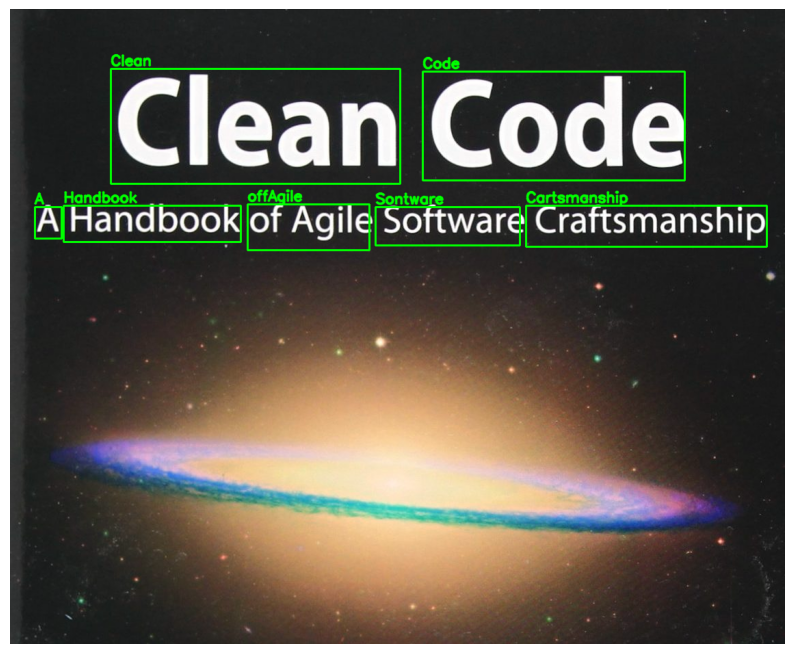


--- All boxes & texts ---
Box=(147,87,423,168) → 'Clean'
Box=(603,91,383,159) → 'Code'
Box=(36,289,39,46) → 'A'
Box=(78,287,259,53) → 'Handbook'
Box=(347,285,178,67) → 'offAgile'
Box=(534,289,211,56) → 'Sontware'
Box=(754,287,352,60) → 'Cartsmanship'

=== Image to Text ===
Clean Code
A Handbook offAgile Sontware Cartsmanship


In [ ]:
if __name__ == "__main__":
    img_file = "cleancode.jpg"
    results, paragraph = detect_and_recognize(img_file)

    print("\n--- All boxes & texts ---")
    for box, txt in results:
        x,y,w,h = box
        print(f"Box=({x},{y},{w},{h}) → '{txt}'")

    print("\n=== Image to Text ===")
    print(paragraph)

## OCR Pipeline

Image → Detection → Cropping → Recognition → Text